# Activation Patching

**Companion to** [research/05-activation-patching.md](../research/05-activation-patching.md)

Activation patching *localizes* where a piece of information is processed: run a **clean** input and a
**corrupted** one, then **transplant** one component's activation from one run into the other and
measure how much the output recovers. It is an *interchange* causal intervention — swapping a real
activation from a counterfactual run rather than nudging the latent along a direction.

**What we will see:**
1. The recovery metric — clean vs corrupted vs a single good patch.
2. A causal-tracing **heatmap** over (layer × position): where the fact lives and how it flows.
3. **Denoising vs noising** answer different questions (sufficiency vs necessity).
4. **Redundancy** hides effects: patching one of two duplicated components under-reports importance.
5. **Attribution patching** — a gradient approximation that is fast but breaks for large activations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## A small routing model we can patch

To patch activations we need a model with an explicit **residual stream** over positions. We use a
tiny "transformer-lite": $T=6$ positions, each a $d$-dim vector, processed by $L=4$ blocks. Each
block mixes information *across positions* (a learned $T\times T$ matrix) and applies a per-position
MLP. The label is the **sign of a scalar planted at one key position** ($p^*=1$); the readout is
taken from the **last position**, so the model must *route* the fact from $p^*$ to the end — exactly
the kind of flow causal tracing reveals.

In [2]:
T, d, L, KEY = 6, 16, 4, 1
key_vec = np.random.randn(d).astype(np.float32); key_vec /= np.linalg.norm(key_vec)

def make_data(n, seed, key_positions=(KEY,)):
    rng = np.random.RandomState(seed)
    s = rng.choice([-1.0, 1.0], n) * (0.8 + 0.4 * rng.random(n))   # planted scalar; sign = label
    R0 = (rng.randn(n, T, d) * 0.5).astype(np.float32)             # distractor embeddings
    for p in key_positions:
        R0[:, p, :] += s[:, None] * key_vec                        # inject the fact
    y = (s > 0).astype(np.int64)
    return R0, y, s

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.mix = nn.Linear(T, T, bias=False)                      # cross-position mixing
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.ReLU(), nn.Linear(4 * d, d))
    def forward(self, R):                                           # R: (B, T, d)
        R = R + torch.einsum('ts,bsd->btd', self.mix.weight, R)
        R = R + self.mlp(R)
        return R

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([Block() for _ in range(L)])
        self.head = nn.Linear(d, 2)
    def run(self, R, patches=None, donor=None):
        # patches: list of (layer, pos); donor: cached activations to copy in
        acts = []
        for l, blk in enumerate(self.blocks):
            R = blk(R)
            if patches:
                R = R.clone()
                for (pl, pt) in patches:
                    if pl == l:
                        R[:, pt, :] = donor[l][:, pt, :]
            acts.append(R)
        logits = self.head(R[:, -1, :])
        return logits, acts

def train(net, R0, y, steps=600):
    opt = torch.optim.Adam(net.parameters(), lr=3e-3); lf = nn.CrossEntropyLoss()
    Rt, yt = torch.tensor(R0), torch.tensor(y)
    for _ in range(steps):
        opt.zero_grad(); logits, _ = net.run(Rt); lf(logits, yt).backward(); opt.step()
    return (net.run(Rt)[0].argmax(1).numpy() == y).mean()

net = Net()
R0, y, s = make_data(3000, 0)
acc = train(net, R0, y)
print(f'model accuracy: {acc:.3f}  (label = sign of the planted scalar at position {KEY})')

model accuracy: 1.000  (label = sign of the planted scalar at position 1)


### What you see

The model solves the task, which means it has learned to carry the planted fact from position
$p^*=1$ through the mixing layers to the last position where the head reads it. We never told it
*how* to route — that routing is exactly what activation patching will now expose, component by
component.

## Experiment 1: Clean, corrupted, and one patch

**Question:** What three numbers define the recovery metric?

We take a batch whose clean label is 1 (scalar $>0$). The **corrupted** input flips the scalar's
sign at the key position, so the model now answers 0. The metric is the **logit difference**
$M = \text{logit}_1 - \text{logit}_0$. We then patch a single clean activation — the key position at
an early layer — into the corrupted run and watch $M$ jump back.

In [3]:
np.random.seed(1)
idx = np.where(s > 0)[0][:256]                       # clean label = 1
Rc = R0[idx].copy()                                  # clean
Rk = Rc.copy(); Rk[:, KEY, :] -= 2 * np.outer(np.ones(len(idx)), key_vec) * (s[idx][:, None])  # flip fact -> corrupted

def metric(logits):
    return (logits[:, 1] - logits[:, 0]).mean().item()

with torch.no_grad():
    Rc_t, Rk_t = torch.tensor(Rc), torch.tensor(Rk)
    logit_clean, acts_clean = net.run(Rc_t)
    logit_corr, _ = net.run(Rk_t)
    M_clean, M_corr = metric(logit_clean), metric(logit_corr)
    # patch the key position at layer 0 (clean -> corrupted run)
    logit_patch, _ = net.run(Rk_t, patches=[(0, KEY)], donor=acts_clean)
    M_patch = metric(logit_patch)
recovery = (M_patch - M_corr) / (M_clean - M_corr)
print(f'M_clean={M_clean:.2f}  M_corr={M_corr:.2f}  M_patch={M_patch:.2f}')
print(f'recovery of patching (layer 0, key pos) = {recovery:.2f}')

M_clean=60.36  M_corr=-47.00  M_patch=12.56
recovery of patching (layer 0, key pos) = 0.55


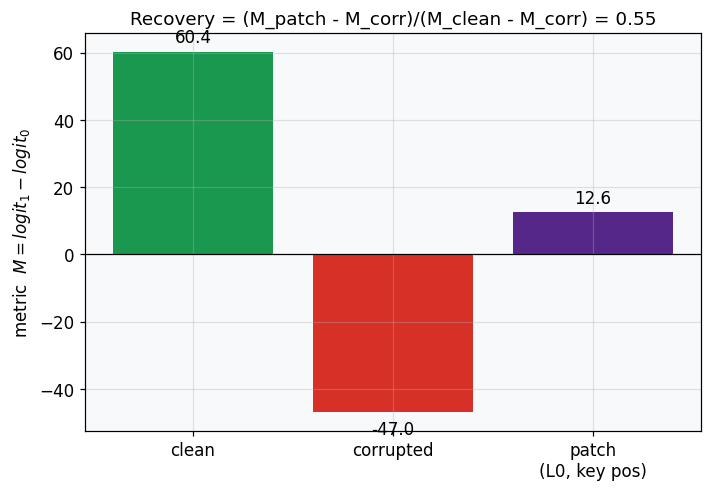

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
bars = ax.bar(['clean', 'corrupted', 'patch\n(L0, key pos)'], [M_clean, M_corr, M_patch],
              color=['#1a9850', '#d73027', '#542788'])
ax.axhline(0, color='k', lw=0.8)
for b, v in zip(bars, [M_clean, M_corr, M_patch]):
    ax.annotate(f'{v:.1f}', (b.get_x() + b.get_width() / 2, v),
                textcoords='offset points', xytext=(0, 6 if v >= 0 else -14), ha='center')
ax.set_ylabel('metric  $M = logit_1 - logit_0$')
ax.set_title(f'Recovery = (M_patch - M_corr)/(M_clean - M_corr) = {recovery:.2f}')
plt.tight_layout(); plt.show()

### What you see

Clean scores a large positive logit difference (confident "1"); corrupting the key position drives it
sharply negative (confident "0"). Patching the *single* clean activation at the key position of layer
0 into the corrupted run pulls the metric partway back — recovery ≈ 0.55 from one early component
alone.

That ratio is the whole game: **recovery measures how much of the answer this single activation
restores.** A value of 0.55 says the key position at layer 0 already carries much of the signal — and
the next experiment shows recovery climbing all the way to 1.0 further along the route, mapping every
component.

## Experiment 2: The causal-tracing heatmap (denoising)

**Question:** Where, across layers and positions, does the fact live — and how does it move?

We sweep every (layer $\ell$, position $t$), patch the clean activation there into the corrupted run,
and record recovery. The resulting heatmap is exactly Meng et al.'s causal trace: bright cells are
where restoring the activation restores the answer.

In [5]:
def recovery_map(denoise=True):
    M = np.zeros((L, T))
    with torch.no_grad():
        for l in range(L):
            for t in range(T):
                if denoise:                      # base = corrupted, patch clean in
                    lp, _ = net.run(Rk_t, patches=[(l, t)], donor=acts_clean)
                    M[l, t] = (metric(lp) - M_corr) / (M_clean - M_corr)
                else:                            # base = clean, patch corrupted in
                    lp, _ = net.run(Rc_t, patches=[(l, t)], donor=acts_corr)
                    M[l, t] = (M_clean - metric(lp)) / (M_clean - M_corr)
    return M

with torch.no_grad():
    _, acts_corr = net.run(Rk_t)
deno = recovery_map(denoise=True)
print('denoising recovery map (rows=layer, cols=position):')
print(np.round(deno, 2))

denoising recovery map (rows=layer, cols=position):
[[ 0.03  0.55  0.04  0.07  0.08  0.18]
 [ 0.    0.18  0.18 -0.03  0.12  0.51]
 [-0.04  0.01  0.1   0.02  0.12  0.8 ]
 [ 0.    0.    0.    0.    0.    1.  ]]


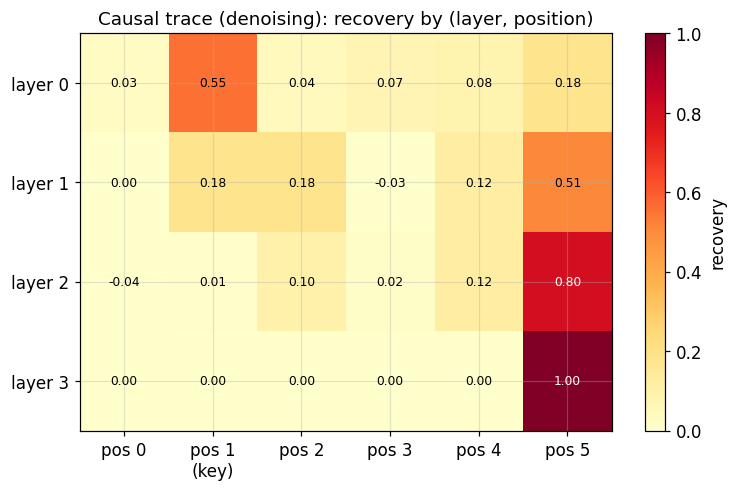

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.6))
im = ax.imshow(deno, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_xticklabels([f'pos {t}' + ('\n(key)' if t == KEY else '') for t in range(T)])
ax.set_yticks(range(L)); ax.set_yticklabels([f'layer {l}' for l in range(L)])
for l in range(L):
    for t in range(T):
        ax.text(t, l, f'{deno[l, t]:.2f}', ha='center', va='center',
                color='black' if deno[l, t] < 0.6 else 'white', fontsize=8)
ax.set_title('Causal trace (denoising): recovery by (layer, position)')
fig.colorbar(im, ax=ax, label='recovery')
plt.tight_layout(); plt.show()

### What you see

The bright cells trace the fact's journey through the network. In the **early layers** recovery
concentrates at the **key position** (pos 1) — that is where the information still sits. In **later
layers** the bright cell migrates toward the **last position**, where the head reads out: the mixing
blocks have transported the fact across the residual stream.

This is what "localization" means concretely — not a single point but a *flow*. It is the same
diagonal-ish pattern Meng et al. found for factual recall, and it is the map that tells Layer B
*which component to edit* if it wants to change the answer.

## Experiment 3: Denoising vs noising — sufficiency vs necessity

**Question:** Do the two patching directions give the same answer?

**Denoising** (patch clean → corrupted) asks *is this component **sufficient** to restore the
answer?* **Noising** (patch corrupted → clean) asks *is it **necessary** — does removing it break the
answer?* We compute both maps and compare.

In [7]:
noise = recovery_map(denoise=False)
print('noising map (necessity):')
print(np.round(noise, 2))
# component-wise difference
diff = deno - noise
print(f'\nmax |denoise - noise| across components = {np.abs(diff).max():.2f}')

noising map (necessity):
[[ 0.03  0.59  0.04  0.08  0.08  0.2 ]
 [ 0.    0.2   0.19 -0.03  0.12  0.54]
 [-0.04  0.01  0.09  0.01  0.12  0.8 ]
 [ 0.    0.    0.    0.    0.    1.  ]]

max |denoise - noise| across components = 0.04


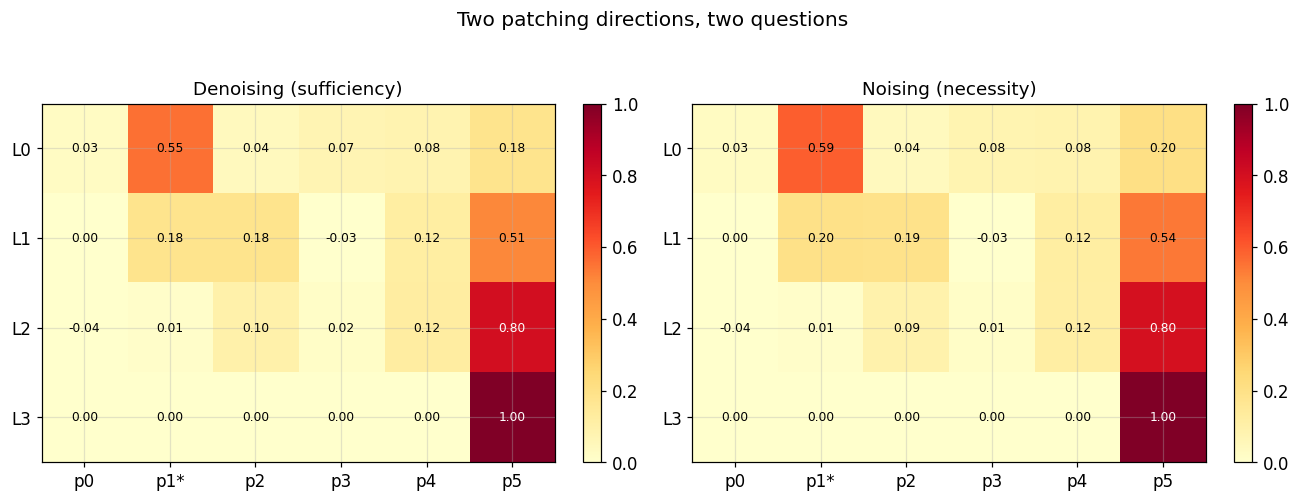

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, M, title in [(axes[0], deno, 'Denoising (sufficiency)'),
                     (axes[1], noise, 'Noising (necessity)')]:
    im = ax.imshow(M, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(T)); ax.set_xticklabels([f'p{t}' + ('*' if t == KEY else '') for t in range(T)])
    ax.set_yticks(range(L)); ax.set_yticklabels([f'L{l}' for l in range(L)])
    for l in range(L):
        for t in range(T):
            ax.text(t, l, f'{M[l, t]:.2f}', ha='center', va='center',
                    color='black' if M[l, t] < 0.6 else 'white', fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Two patching directions, two questions', y=1.03)
plt.tight_layout(); plt.show()

### What you see

The two maps are **nearly identical** (max component difference ≤ 0.04). That is itself a finding: in
a clean *single-path* circuit, a component that is sufficient to restore the answer is also necessary
to maintain it — sufficiency and necessity coincide.

They come apart only when information is **redundant** or backed up: then a component can be sufficient
(its clean copy restores the answer) yet *not* necessary (ablating it changes little, because a
duplicate compensates) — the regime of the next experiment. The practical rule from Heimersheim &
Nanda stands regardless: since the two measure different things in general, **state which direction
you ran** — which is why Latent-Anything forces the caller to pick `mode="denoise"` or `"noise"`.

## Experiment 4 (limitation): redundancy hides effects

**Question:** What if the same information is stored in two places?

We train a model where the fact is planted at **two** key positions. Now patching/ablating just one
of them barely moves the output — its twin still carries the fact. Only ablating *both* reveals the
information's true importance. Single-component patching **under-reports**.

In [9]:
KEY2 = 3
netR = Net()
R0r, yr, sr = make_data(3000, 5, key_positions=(KEY, KEY2))   # fact duplicated at pos 1 and 3
accR = train(netR, R0r, yr)

idx = np.where(sr > 0)[0][:256]
Rc = R0r[idx].copy()
Rk = Rc.copy()
for p in (KEY, KEY2):
    Rk[:, p, :] -= 2 * np.outer(np.ones(len(idx)), key_vec) * (sr[idx][:, None])
with torch.no_grad():
    Rc_t, Rk_t = torch.tensor(Rc), torch.tensor(Rk)
    logit_clean, acts_clean = netR.run(Rc_t)
    M_clean = metric(logit_clean)
    M_corr = metric(netR.run(Rk_t)[0])
    def noise_effect(positions):                 # ablate (noise) given key positions at layer 0
        lp, _ = netR.run(Rc_t, patches=[(0, p) for p in positions], donor=acts_corr_r)
        return (M_clean - metric(lp)) / (M_clean - M_corr)
    _, acts_corr_r = netR.run(Rk_t)
    eff_1 = noise_effect([KEY])
    eff_2 = noise_effect([KEY2])
    eff_both = noise_effect([KEY, KEY2])
print(f'model accuracy (redundant): {accR:.3f}')
print(f'noise key pos 1 only  -> effect {eff_1:.2f}')
print(f'noise key pos 3 only  -> effect {eff_2:.2f}')
print(f'noise both            -> effect {eff_both:.2f}')
print(f'sum of singles = {eff_1 + eff_2:.2f}  vs both = {eff_both:.2f}')

model accuracy (redundant): 1.000
noise key pos 1 only  -> effect 0.41
noise key pos 3 only  -> effect 0.41
noise both            -> effect 0.81
sum of singles = 0.82  vs both = 0.81


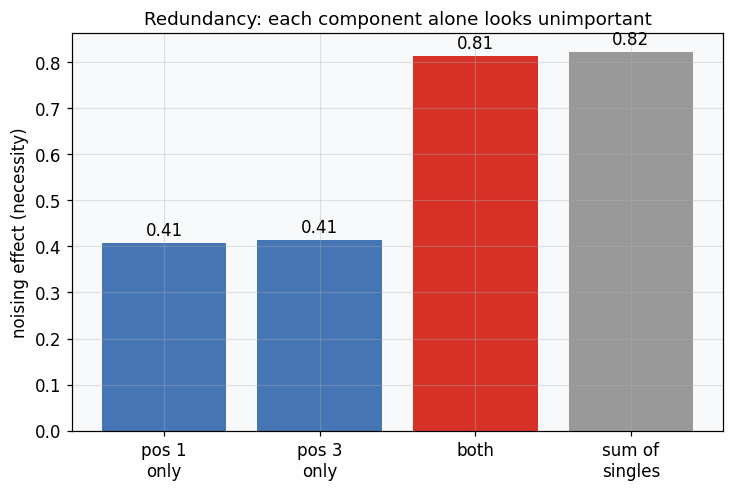

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 4.6))
bars = ax.bar(['pos 1\nonly', 'pos 3\nonly', 'both', 'sum of\nsingles'],
              [eff_1, eff_2, eff_both, eff_1 + eff_2],
              color=['#4575b4', '#4575b4', '#d73027', '#999999'])
for b, v in zip(bars, [eff_1, eff_2, eff_both, eff_1 + eff_2]):
    ax.annotate(f'{v:.2f}', (b.get_x() + b.get_width() / 2, v),
                textcoords='offset points', xytext=(0, 5), ha='center')
ax.set_ylabel('noising effect (necessity)')
ax.set_title('Redundancy: each component alone looks unimportant')
plt.tight_layout(); plt.show()

### What you see

Ablating either key position **on its own** accounts for only ~0.41 of the break — its duplicate still
feeds the answer through. The full effect (~0.81) appears only when **both** are ablated together. A
researcher scanning one component at a time would rate each position as merely *moderately* important
and miss that together they are decisive.

This is the redundancy caveat from the note. Here the two contributions happen to add up (parallel
redundancy); *serial* redundancy is worse — a backup component can switch on only once the first is
ablated, hiding the first's importance entirely. Either way, robust conclusions require patching
**sets** of components, not one at a time.

## Experiment 5: Attribution patching — fast but approximate

**Question:** Can we skip the per-component forward passes with a gradient — and at what cost?

Attribution patching estimates recovery with a first-order term
$(a^{clean}-a^{corr})^\top \partial M/\partial a$, computable for **all** components from a single
backward pass. We compare it against the *true* denoising recovery from Experiment 2, and check where
the linear approximation breaks.

In [11]:
# work on the ORIGINAL (non-redundant) model / batch used in exp1-2
np.random.seed(1)
idx = np.where(s > 0)[0][:256]
Rc_t = torch.tensor(R0[idx].copy())
Rk_np = R0[idx].copy(); Rk_np[:, KEY, :] -= 2 * np.outer(np.ones(len(idx)), key_vec) * (s[idx][:, None])
Rk_t = torch.tensor(Rk_np)

# clean activations (donor) and corrupted activations WITH grad
with torch.no_grad():
    _, acts_clean = net.run(Rc_t)
acts_corr_grad = []
R = Rk_t.clone().requires_grad_(False)
for blk in net.blocks:
    R = blk(R); R.retain_grad(); acts_corr_grad.append(R)
M_t = (net.head(R[:, -1, :])[:, 1] - net.head(R[:, -1, :])[:, 0]).mean()
M_t.backward()

denom = (M_clean - M_corr)
attr_map = np.zeros((L, T)); true_map = deno
for l in range(L):
    g = acts_corr_grad[l].grad                       # (B,T,d)
    delta = acts_clean[l] - acts_corr_grad[l].detach()
    attr_map[l] = ((delta * g).sum(-1).mean(0) / denom).numpy()
act_norm = np.array([[acts_clean[l][:, t, :].norm(dim=-1).mean().item() for t in range(T)] for l in range(L)])
print('correlation(attr, true) =', np.corrcoef(attr_map.ravel(), true_map.ravel())[0, 1].round(3))

correlation(attr, true) = 1.0


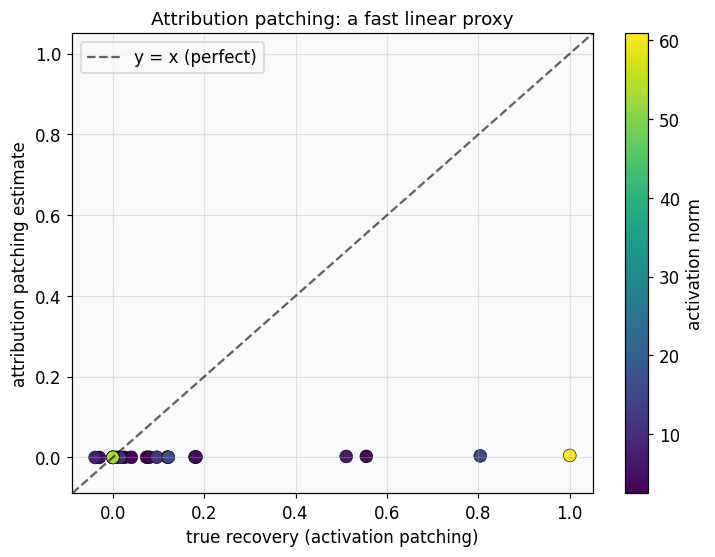

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 5.2))
sc = ax.scatter(true_map.ravel(), attr_map.ravel(), c=act_norm.ravel(),
                cmap='viridis', s=70, edgecolor='k', linewidth=0.4)
lim = [min(true_map.min(), attr_map.min()) - 0.05, max(true_map.max(), attr_map.max()) + 0.05]
ax.plot(lim, lim, 'k--', alpha=0.6, label='y = x (perfect)')
ax.set_xlabel('true recovery (activation patching)')
ax.set_ylabel('attribution patching estimate')
ax.set_title('Attribution patching: a fast linear proxy')
fig.colorbar(sc, ax=ax, label='activation norm')
ax.legend(loc='upper left'); ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout(); plt.show()

### What you see

The gradient estimate tracks the true recovery almost perfectly here (correlation ≈ 1.0), yet it came
from a *single* backward pass instead of $L\times T$ forward passes — the speed-up that lets
attribution patching scan models with millions of components. Points are coloured by activation norm
to probe the known weak spot.

The caveat is structural, and *absent* in this minimal net: in real transformers the linear
approximation degrades for **large residual-stream activations** and where **LayerNorm** makes
derivatives vanish. Our toy has neither, so attribution is near-exact — but on real models attribution
patching stays an **exploratory** tool whose hits must be confirmed with true patching before they are
trusted.

## Summary / Key Takeaways

- **Exp 1** — Patching transplants one activation between a clean and a corrupted run; **recovery**
  $=(M_{patch}-M_{corr})/(M_{clean}-M_{corr})$ measures how much that component restores the answer.
- **Exp 2** — Sweeping (layer × position) draws a **causal-tracing heatmap**: the fact sits at the key
  position early and flows to the readout position later.
- **Exp 3** — Denoising vs noising ask **sufficiency** vs **necessity**; they coincide in a clean
  single-path circuit and diverge only under redundancy — always state which direction you ran.
- **Exp 4** — **Redundancy hides effects**: with duplicated information, each component alone looks
  only moderately important and only joint ablation reveals the truth — single-component patching
  under-reports.
- **Exp 5** — **Attribution patching** approximates recovery with one backward pass (here near-exact,
  massively cheaper); on real nets with LayerNorm or large activations it degrades — an exploratory
  tool, not a verdict.
